##  Section 1: Imports and configuration

In [8]:
# ============================================================
# Section 1: Imports and configuration
# ============================================================
import os
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from flax import linen as nn
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

NUM_CLASSES = 4
PARTICLE_NAMES = ['Pion', 'Kaon', 'Proton', 'Electron']
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

REAL_DATA_CSV = "/kaggle/input/rawreal-data-ao2d-lhc23zzh0544122/pid_features_real.csv"
MODEL_PATH = "/kaggle/input/models/robertforynski/fse-attention-dpg-cuts/jax/default/1/full_DPG_JAX_FSE_Attention.pkl"

# Exactly 25 features — matches the trained model's input dim.
# The 4 bayes_*_missing flags are always included (appended after base features).
TRAINING_FEATURES = [
    'pt', 'eta', 'phi',
    'tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el',
    'tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el',
    'bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el',
    'dca_xy', 'dca_z',
    'has_tpc', 'has_tof',
    # These 4 missing-indicator columns must always be present (trained model expects them)
    'bayes_prob_pi_missing', 'bayes_prob_ka_missing',
    'bayes_prob_pr_missing', 'bayes_prob_el_missing',
]

DETECTOR_GROUPS = {
    'tpc':        ['tpc_signal', 'tpc_nsigma_pi', 'tpc_nsigma_ka', 'tpc_nsigma_pr', 'tpc_nsigma_el'],
    'tof':        ['tof_beta', 'tof_nsigma_pi', 'tof_nsigma_ka', 'tof_nsigma_pr', 'tof_nsigma_el'],
    'bayes':      ['bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el'],
    'kinematics': ['pt', 'eta', 'phi', 'dca_xy', 'dca_z'],
}

MOMENTUM_RANGES = {
    'mr_0_1':  {'name': '0–1 GeV/c (TPC Saturation)',  'min': 0.0,  'max': 1.0},
    'mr_1_3':  {'name': '1–3 GeV/c (TOF Transition)',  'min': 1.0,  'max': 3.0},
    'mr_full': {'name': 'Full Spectrum (0–∞ GeV/c)',   'min': 0.0,  'max': 100.0},
}

# DPG cuts — must match training exactly
TRACK_SELECTIONS = {
    'event':      {'vz_max': 10.0},
    'kinematics': {'eta_min': -0.8, 'eta_max': 0.8},
    'dca':        {'dca_xy_max': 0.105, 'dca_z_max': 0.12},
    'tpc':        {'tpc_clusters_min': 70},
    'its':        {'its_clusters_min': 3},
}
TRACK_QUALITY_FILTER = {
    'tpc_clusters_min': 70,
    'momentum_min': 0.01,
    'remove_negative_chi2': True,
}

## Section 2: FSE model

In [9]:
# ============================================================
# Section 2: FSE model — 4 groups to match trained weights
# ============================================================
class JAX_FSE_Attention(nn.Module):
    hidden_dim: int = 64
    num_heads: int = 4
    num_classes: int = 4
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, group_mask, training=False):
        batch_size = x.shape[0]
        num_groups = group_mask.shape[1]          # will be 4
        feat_proj = nn.Dense(self.hidden_dim * num_groups)(x)
        feat_proj = feat_proj.reshape(batch_size, num_groups, self.hidden_dim)
        feat_proj = feat_proj * group_mask[:, :, None]
        attn_mask = group_mask[:, None, None, :]
        feat_attn = nn.MultiHeadDotProductAttention(num_heads=self.num_heads)(
            feat_proj, feat_proj, mask=attn_mask
        )
        feat_attn = nn.LayerNorm()(feat_attn)
        gates = nn.sigmoid(nn.Dense(self.hidden_dim)(feat_attn))
        feat_gated = feat_attn * gates
        denom = jnp.clip(jnp.sum(group_mask, axis=1, keepdims=True), 1.0)
        pooled = jnp.sum(feat_gated * group_mask[:, :, None], axis=1) / denom
        x = nn.Dense(128)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)
        return nn.Dense(self.num_classes)(x)


## Section 3: Load model

In [10]:
# ============================================================
# Section 3: Load model
# ============================================================
with open(MODEL_PATH, "rb") as f:
    fse_obj = pickle.load(f)

print("Loaded object type:", type(fse_obj))
if isinstance(fse_obj, dict):
    print("Top-level keys:", list(fse_obj.keys()))

def extract_params(obj):
    if isinstance(obj, dict):
        for key in ["params", "modelparams", "model_params", "state", "model_state"]:
            if key in obj:
                val = obj[key]
                return val.params if hasattr(val, "params") else val
        if "results" in obj and isinstance(obj["results"], dict):
            return extract_params(obj["results"])
        if "models" in obj and isinstance(obj["models"], dict):
            if "JAX_FSE_Attention" in obj["models"]:
                return extract_params(obj["models"]["JAX_FSE_Attention"])
    if hasattr(obj, "params"):
        return obj.params
    raise KeyError("Could not find model parameters in the loaded pickle.")

def extract_hyperparameters(obj):
    if isinstance(obj, dict):
        for key in ["hyperparameters", "hparams", "config"]:
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
        if "results" in obj and isinstance(obj["results"], dict):
            hp = extract_hyperparameters(obj["results"])
            if hp is not None:
                return hp
    return {"hidden_dim": 128, "num_heads": 8, "dropout_rate": 0.4}

params = extract_params(fse_obj)
hyper  = extract_hyperparameters(fse_obj)
print("Using hyperparameters:", hyper)

model = JAX_FSE_Attention(
    hidden_dim=hyper.get("hidden_dim", 128),
    num_heads=hyper.get("num_heads", 8),
    num_classes=NUM_CLASSES,
    dropout_rate=hyper.get("dropout_rate", 0.4),
)

@jax.jit
def fse_forward(params, x, group_mask):
    return model.apply({"params": params}, x, group_mask, training=False)


Loaded object type: <class 'dict'>
Top-level keys: ['model_type', 'hyperparameters', 'train_losses', 'val_accuracies', 'best_val_acc', 'train_acc', 'test_acc', 'train_probs', 'test_probs', 'y_pred_test', 'y_test', 'detector_modes', 'params']
Using hyperparameters: {'hidden_dim': 128, 'num_heads': 8, 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'batch_size': 256, 'num_epochs': 100, 'patience': 30}


## Section 4: Load real data

In [11]:
# ============================================================
# Section 4: Load real data + quality assessment
# ============================================================
print("\n" + "="*80)
print("SECTION 7.1: REAL DATA LOADING & QUALITY ASSESSMENT")
print("="*80)

print(f"\nLoading real data: {REAL_DATA_CSV}...")
df_real = pd.read_csv(
    REAL_DATA_CSV,
    na_values=['-', 'nan', 'null', 'NaN', 'NULL', ''],
    keep_default_na=True,
    on_bad_lines='skip'
)
print("✓ Loaded successfully")

# ── Basic statistics ──────────────────────────────────
print("\n" + "─"*80)
print("7.1.1: BASIC DATA STATISTICS")
print("─"*80)
n_rows, n_cols = df_real.shape
mem_gb = df_real.memory_usage(deep=True).sum() / 1e9
print(f"\nShape: {df_real.shape}")
print(f"Total rows (tracks): {n_rows:,}")
print(f"Total columns: {n_cols}")
print(f"Memory usage: {mem_gb:.2f} GB")
print(f"\nColumns present ({n_cols}):  {', '.join(df_real.columns.tolist())}")

# ── Missing data ──────────────────────────────────────
print("\n" + "─"*80)
print("7.1.2: MISSING DATA ANALYSIS")
print("─"*80)
missing = df_real.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ["Column", "Missing Count"]
missing["Missing %"] = (missing["Missing Count"] / n_rows * 100).round(6)
if len(missing):
    print()
    print(missing.to_string(index=False))
else:
    print("\n✓ No missing values found")

# ── Track quality distribution ────────────────────────
print("\n" + "─"*80)
print("7.1.3: TRACK QUALITY DISTRIBUTION")
print("─"*80)

pt_min, pt_max = df_real["pt"].min(), df_real["pt"].max()
eta_min, eta_max = df_real["eta"].min(), df_real["eta"].max()
phi_min, phi_max = df_real["phi"].min(), df_real["phi"].max()
print(f"\nKinematic ranges:")
print(f"  pT: {pt_min:.4f} — {pt_max:.4f} GeV/c")
print(f"  η:  {eta_min:.4f} — {eta_max:.4f}")
print(f"  φ:  {phi_min:.4f} — {phi_max:.4f}")

print(f"\nDPG Track Selections (applied during O2Physics extraction):")
sel_eta   = (df_real["eta"].between(-0.8, 0.8, inclusive="both")).sum()
sel_dcaxy = (df_real["dca_xy"].abs() < 0.105).sum() if "dca_xy" in df_real.columns else n_rows
sel_dcaz  = (df_real["dca_z"].abs()  < 0.12 ).sum() if "dca_z"  in df_real.columns else n_rows
sel_tpc   = (df_real["tpc_nclusters"] >= 70  ).sum() if "tpc_nclusters" in df_real.columns else n_rows
print(f"  η ∈ [-0.8, 0.8]:           {sel_eta:,} ({sel_eta/n_rows*100:.1f}%)")
print(f"  DCA_xy < 0.105 cm:         {sel_dcaxy:,} ({sel_dcaxy/n_rows*100:.1f}%)")
print(f"  DCA_z < 0.12 cm:           {sel_dcaz:,} ({sel_dcaz/n_rows*100:.1f}%)")
print(f"  TPC clusters ≥ 70:         {sel_tpc:,} ({sel_tpc/n_rows*100:.1f}%)")

if "vz" in df_real.columns:
    vz_min, vz_max_val = df_real["vz"].min(), df_real["vz"].max()
    vz_ok = (df_real["vz"].abs() < 10.0).sum()
    print(f"\nCollision vertex distribution:")
    print(f"  vZ min: {vz_min:.2f} cm")
    print(f"  vZ max: {vz_max_val:.2f} cm")
    print(f"  vZ within ±10 cm:    {vz_ok:,} ({vz_ok/n_rows*100:.1f}%)")

print(f"\nDetector availability:")
has_tpc = df_real["has_tpc"].fillna(0).astype(bool)
has_tof = df_real["has_tof"].fillna(0).astype(bool)
tpc_only   = ( has_tpc & ~has_tof).sum()
tof_only   = (~has_tpc &  has_tof).sum()
both       = ( has_tpc &  has_tof).sum()
neither    = (~has_tpc & ~has_tof).sum()
print(f"  TPC only:       {tpc_only:,} ({tpc_only/n_rows*100:.1f}%)")
print(f"  TOF only:       {tof_only:,} ({tof_only/n_rows*100:.1f}%)")
print(f"  Both TPC+TOF:   {both:,} ({both/n_rows*100:.1f}%)")
print(f"  Neither:        {neither:,} ({neither/n_rows*100:.1f}%)")

# ── Bayesian PID availability ─────────────────────────
print("\n" + "─"*80)
print("7.1.4: BAYESIAN PID AVAILABILITY")
print("─"*80)
bayes_cols = ['bayes_prob_pi', 'bayes_prob_ka', 'bayes_prob_pr', 'bayes_prob_el']
bayes_avail = (df_real[bayes_cols].fillna(0).sum(axis=1) > 0).sum()
bayes_miss  = n_rows - bayes_avail
print(f"\nBayesian PID available (sum > 0):    {bayes_avail:,} ({bayes_avail/n_rows*100:.1f}%)")
print(f"Bayesian PID missing (token):         {bayes_miss:,} ({bayes_miss/n_rows*100:.1f}%)")
print("\n✓ DATA QUALITY ASSESSMENT COMPLETE")

# ============================================================
# Section 4b: Apply DPG cuts
# ============================================================
print("\n" + "="*80)
print("SECTION 4b: APPLYING DPG CUTS")
print("="*80)

n_before = len(df_real)

if TRACK_QUALITY_FILTER['remove_negative_chi2'] and 'tpc_chi2' in df_real.columns:
    df_real = df_real[df_real['tpc_chi2'] >= 0].copy()
if 'pt' in df_real.columns:
    df_real = df_real[df_real['pt'] >= TRACK_QUALITY_FILTER['momentum_min']].copy()
if 'vz' in df_real.columns:
    df_real = df_real[df_real['vz'].abs() < TRACK_SELECTIONS['event']['vz_max']].copy()
if 'eta' in df_real.columns:
    df_real = df_real[df_real['eta'].between(
        TRACK_SELECTIONS['kinematics']['eta_min'],
        TRACK_SELECTIONS['kinematics']['eta_max'], inclusive="neither")].copy()
if 'dca_xy' in df_real.columns:
    df_real = df_real[df_real['dca_xy'].abs() < TRACK_SELECTIONS['dca']['dca_xy_max']].copy()
if 'dca_z' in df_real.columns:
    df_real = df_real[df_real['dca_z'].abs() < TRACK_SELECTIONS['dca']['dca_z_max']].copy()

tpc_cluster_col = next((c for c in ['tpc_nclusters', 'tpc_clusters'] if c in df_real.columns), None)
if tpc_cluster_col:
    df_real = df_real[df_real[tpc_cluster_col] >= TRACK_SELECTIONS['tpc']['tpc_clusters_min']].copy()
its_cluster_col = next((c for c in ['its_nclusters', 'its_clusters'] if c in df_real.columns), None)
if its_cluster_col:
    df_real = df_real[df_real[its_cluster_col] >= TRACK_SELECTIONS['its']['its_clusters_min']].copy()

print(f"Shape after DPG cuts: {df_real.shape}  (removed {n_before - len(df_real):,} tracks)")



SECTION 7.1: REAL DATA LOADING & QUALITY ASSESSMENT

Loading real data: /kaggle/input/rawreal-data-ao2d-lhc23zzh0544122/pid_features_real.csv...
✓ Loaded successfully

────────────────────────────────────────────────────────────────────────────────
7.1.1: BASIC DATA STATISTICS
────────────────────────────────────────────────────────────────────────────────

Shape: (7473918, 34)
Total rows (tracks): 7,473,918
Total columns: 34
Memory usage: 2.03 GB

Columns present (34):  event_id, track_id, px, py, pz, pt, p, eta, phi, theta, charge, track_type, tpc_signal, tpc_nsigma_pi, tpc_nsigma_ka, tpc_nsigma_pr, tpc_nsigma_el, tpc_nclusters, tpc_chi2, tof_beta, tof_mass, tof_nsigma_pi, tof_nsigma_ka, tof_nsigma_pr, tof_nsigma_el, bayes_prob_pi, bayes_prob_ka, bayes_prob_pr, bayes_prob_el, has_tpc, has_tof, dca_xy, dca_z, vz

────────────────────────────────────────────────────────────────────────────────
7.1.2: MISSING DATA ANALYSIS
───────────────────────────────────────────────────────────────

## Section 5: Preprocess for inference

In [12]:
# ============================================================
# Section 5: Feature analysis + preprocessing
# ============================================================
print("\n" + "="*80)
print("SECTION 7.2: FEATURE ANALYSIS FOR REAL DATA")
print("="*80)

df_proc = df_real.copy()
bayes_features = DETECTOR_GROUPS["bayes"]

# Imputation
for feat in DETECTOR_GROUPS["tof"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(0.0 if feat == "tof_beta" else 999.0)
for feat in DETECTOR_GROUPS["tpc"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(0.0 if feat == "tpc_signal" else 999.0)
for feat in bayes_features:
    miss_col = f"{feat}_missing"
    if feat in df_proc.columns:
        miss = (df_proc[feat] == 0) | (df_proc[feat].isna())
        df_proc[miss_col] = miss.astype("float32")
        df_proc.loc[miss, feat] = -0.25
    else:
        df_proc[feat]     = -0.25
        df_proc[miss_col] = 1.0
for feat in DETECTOR_GROUPS["kinematics"]:
    if feat in df_proc.columns:
        df_proc[feat] = df_proc[feat].fillna(df_proc[feat].median())
for col in ["has_tpc", "has_tof"]:
    df_proc[col] = df_proc[col].fillna(0.0) if col in df_proc.columns else 0.0

# Feature availability report
avail = [f for f in TRAINING_FEATURES if f in df_proc.columns]
print(f"\nAvailable training features: {len(avail)}/{len(TRAINING_FEATURES)}")
print(f"Features: {', '.join(avail)}")

missing_cols = [f for f in TRAINING_FEATURES if f not in df_proc.columns]
if missing_cols:
    raise ValueError(f"Missing features: {missing_cols}")

# ── PID detector feature distributions ───────────────────────
print("\n" + "─"*80)
print("PID Detector Feature Distributions")
print("─"*80)

tpc_valid = (df_proc["tpc_signal"] > 0)
print(f"\nTPC Signal (dE/dx):")
print(f"  Count (> 0):  {tpc_valid.sum():,} ({tpc_valid.mean()*100:.1f}%)")
print(f"  Mean:          {df_proc.loc[tpc_valid,'tpc_signal'].mean():.2f}")
print(f"  Std Dev:     {df_proc.loc[tpc_valid,'tpc_signal'].std():.2f}")
print(f"  Median:           {df_proc.loc[tpc_valid,'tpc_signal'].median():.2f}")

tof_valid = (df_proc["tof_beta"] > 0) & (df_proc["tof_beta"] < 2)
print(f"\nTOF Beta:")
print(f"  Count (0 < β < 2):  {tof_valid.sum():,} ({tof_valid.mean()*100:.1f}%)")
print(f"  Mean:                  {df_proc.loc[tof_valid,'tof_beta'].mean():.4f}")
print(f"  Std Dev:               {df_proc.loc[tof_valid,'tof_beta'].std():.4f}")
print(f"  Median:                {df_proc.loc[tof_valid,'tof_beta'].median():.4f}")

bayes_avail = (df_proc[bayes_features].replace(-0.25, np.nan).notna().all(axis=1)).sum()
print(f"\nBayesian Probabilities:")
print(f"  Available:    {bayes_avail:,} ({bayes_avail/len(df_proc)*100:.1f}%)")

# ── Build feature matrix ──────────────────────────────────────
X_real   = df_proc[TRAINING_FEATURES].values.astype("float32")
X_scaled = X_real.copy()
n_nan    = np.isnan(X_real).sum()
if n_nan:
    print(f"\n   Found {n_nan} NaN values, replacing with 0")
    X_real   = np.nan_to_num(X_real, nan=0.0)
    X_scaled = X_real.copy()

scaler       = StandardScaler()
skip_scaling = {"has_tpc", "has_tof"} | {f"{f}_missing" for f in bayes_features}
for i, feat in enumerate(TRAINING_FEATURES):
    if feat in skip_scaling:
        continue
    col = X_real[:, i]
    if feat in bayes_features:
        real_mask = col != -0.25
        if real_mask.sum() > 0:
            scaler.fit(col[real_mask].reshape(-1, 1))
            X_scaled[real_mask, i] = scaler.transform(col[real_mask].reshape(-1, 1)).reshape(-1)
    else:
        scaler.fit(col.reshape(-1, 1))
        X_scaled[:, i] = scaler.transform(col.reshape(-1, 1)).reshape(-1)

print(f"\n✓ Feature matrix shape: {X_scaled.shape}")
print(f"✓ Scaled feature matrix shape: {X_scaled.shape}")

bayes_present = (
    df_proc[['bayes_prob_pi_missing', 'bayes_prob_ka_missing',
             'bayes_prob_pr_missing', 'bayes_prob_el_missing']]
    .values.mean(axis=1) < 1.0
).astype("float32")

group_masks = np.stack([
    df_proc["has_tpc"].values.astype("float32"),
    df_proc["has_tof"].values.astype("float32"),
    bayes_present,
    np.ones(len(df_proc), dtype="float32"),
], axis=1)

print(f"\nGroup mask: {group_masks.shape}")
assert X_scaled.shape[1] == 25, f"Expected 25 features, got {X_scaled.shape[1]}"
assert group_masks.shape[1] == 4, f"Expected 4 groups, got {group_masks.shape[1]}"



SECTION 7.2: FEATURE ANALYSIS FOR REAL DATA

Available training features: 25/25
Features: pt, eta, phi, tpc_signal, tpc_nsigma_pi, tpc_nsigma_ka, tpc_nsigma_pr, tpc_nsigma_el, tof_beta, tof_nsigma_pi, tof_nsigma_ka, tof_nsigma_pr, tof_nsigma_el, bayes_prob_pi, bayes_prob_ka, bayes_prob_pr, bayes_prob_el, dca_xy, dca_z, has_tpc, has_tof, bayes_prob_pi_missing, bayes_prob_ka_missing, bayes_prob_pr_missing, bayes_prob_el_missing

────────────────────────────────────────────────────────────────────────────────
PID Detector Feature Distributions
────────────────────────────────────────────────────────────────────────────────

TPC Signal (dE/dx):
  Count (> 0):  7,473,860 (100.0%)
  Mean:          63167.64
  Std Dev:     24316403.84
  Median:           55.93

TOF Beta:
  Count (0 < β < 2):  2,471,144 (33.1%)
  Mean:                  0.9050
  Std Dev:               0.1852
  Median:                0.9765

Bayesian Probabilities:
  Available:    2,474,225 (33.1%)

✓ Feature matrix shape: (7473

## Section 6: Inference

In [13]:
# ============================================================
# Section 6: Inference
# ============================================================
print("\n" + "="*80)
print("SECTION 7.3: FSE ATTENTION INFERENCE ON REAL DATA")
print("="*80)

batch_size = 4096
n          = len(df_proc)
y_pred     = np.empty(n, dtype=np.int32)
y_proba    = np.empty((n, NUM_CLASSES), dtype=np.float32)
confidence = np.empty(n, dtype=np.float32)

print("\nStep 1: Running inference...")
for start in range(0, n, batch_size):
    end    = min(start + batch_size, n)
    logits = fse_forward(
        params,
        jnp.array(X_scaled[start:end]),
        jnp.array(group_masks[start:end])
    )
    probs = np.array(jax.nn.softmax(logits, axis=-1))
    y_proba[start:end]    = probs
    y_pred[start:end]     = probs.argmax(axis=1)
    confidence[start:end] = probs.max(axis=1)

df_proc["ml_pred_class"] = y_pred
df_proc["ml_prob_pi"]    = y_proba[:, 0]
df_proc["ml_prob_ka"]    = y_proba[:, 1]
df_proc["ml_prob_pr"]    = y_proba[:, 2]
df_proc["ml_prob_el"]    = y_proba[:, 3]
df_proc["ml_confidence"] = confidence

preds_made = n
print(f"✓ Inference complete: {preds_made:,} predictions")
print(f"\nStep 2: Combining predictions...")
print(f"Predictions made: {preds_made:,} / {n:,} ({preds_made/n*100:.1f}%)")
print(f"\n✓ Added ML predictions to dataframe")


SECTION 7.3: FSE ATTENTION INFERENCE ON REAL DATA

Step 1: Running inference...
✓ Inference complete: 7,473,915 predictions

Step 2: Combining predictions...
Predictions made: 7,473,915 / 7,473,915 (100.0%)

✓ Added ML predictions to dataframe


## Section 7: Save output

In [14]:
# ============================================================
# Section 7: Save output
# ============================================================
OUTPUT_CSV = "ml_predictions_real_data_FSE.csv"
df_proc.to_csv(OUTPUT_CSV, index=False)
size_gb = os.path.getsize(OUTPUT_CSV) / 1e9

print("\n" + "─"*80)
print("OUTPUT FILE SUMMARY")
print("─"*80)
print(f"{OUTPUT_CSV} (~{size_gb:.1f} GB)")
print(f"\nFile contains:")
print(f"  • Original features (pt, eta, phi, tpc_signal, tof_beta, etc.)")
print(f"  • ML predictions (ml_pred_class: 0=π, 1=K, 2=p, 3=e)")
print(f"  • ML probabilities (ml_prob_pi, ml_prob_ka, ml_prob_pr, ml_prob_el)")
print(f"  • Confidence scores (ml_confidence: 0-1)")


────────────────────────────────────────────────────────────────────────────────
OUTPUT FILE SUMMARY
────────────────────────────────────────────────────────────────────────────────
ml_predictions_real_data_FSE.csv (~2.3 GB)

File contains:
  • Original features (pt, eta, phi, tpc_signal, tof_beta, etc.)
  • ML predictions (ml_pred_class: 0=π, 1=K, 2=p, 3=e)
  • ML probabilities (ml_prob_pi, ml_prob_ka, ml_prob_pr, ml_prob_el)
  • Confidence scores (ml_confidence: 0-1)


## Section 8: Basic validation

In [15]:
# ============================================================
# Section 8: Physics validation
# ============================================================
print("\n" + "="*80)
print("PHYSICS VALIDATION")
print("="*80)

# ── TPC dE/dx ordering ────────────────────────────────
print("\n" + "─"*80)
print("7.5.1: TPC dE/dx ORDERING VALIDATION")
print("─"*80)
print("\nExpected: π < K < p (by mass dependence)")
print(f"\n{'Particle':<16}{'Mean dE/dx':>12}")
print("-"*40)
tpc_means = {}
for i, name in enumerate(PARTICLE_NAMES):
    mask = (df_proc["ml_pred_class"] == i) & (df_proc["tpc_signal"] > 0)
    mean_val = df_proc.loc[mask, "tpc_signal"].mean() if mask.sum() > 0 else float("nan")
    tpc_means[name] = mean_val
    print(f"{name:<16}{mean_val:>12.2f}")

print(f"\nVerification:")
pi_k = tpc_means['Pion']  < tpc_means['Kaon']
k_p  = tpc_means['Kaon']  < tpc_means['Proton']
print(f"  π < K: {'✓' if pi_k else '✗'} ({tpc_means['Pion']:.2f} < {tpc_means['Kaon']:.2f})")
print(f"  K < p: {'✓' if k_p  else '✗'} ({tpc_means['Kaon']:.2f} < {tpc_means['Proton']:.2f})")

# ── TOF β ordering ────────────────────────────────────
print("\n" + "─"*80)
print("7.5.2: TOF β ORDERING VALIDATION")
print("─"*80)
print("\nExpected: π > K > p (lighter particles are faster)")
print(f"\n{'Particle':<20}{'Mean β':>10}")
print("-"*40)
tof_means = {}
for i, name in enumerate(PARTICLE_NAMES):
    mask = (df_proc["ml_pred_class"] == i) & (df_proc["tof_beta"] > 0) & (df_proc["tof_beta"] < 2)
    mean_val = df_proc.loc[mask, "tof_beta"].mean() if mask.sum() > 0 else float("nan")
    tof_means[name] = mean_val
    print(f"{name:<20}{mean_val:>10.4f}")

print(f"\nVerification:")
pi_k = tof_means['Pion']  > tof_means['Kaon']
k_p  = tof_means['Kaon']  > tof_means['Proton']
print(f"  π > K: {'✓' if pi_k else '✗'} ({tof_means['Pion']:.4f} > {tof_means['Kaon']:.4f})")
print(f"  K > p: {'✓' if k_p  else '✗'} ({tof_means['Kaon']:.4f} > {tof_means['Proton']:.4f})")

# ── Confidence statistics ─────────────────────────────
print("\n" + "─"*80)
print("7.5.3: ML CONFIDENCE STATISTICS")
print("─"*80)
conf = df_proc["ml_confidence"]
print(f"\nMean confidence:     {conf.mean():.4f}")
print(f"Median confidence:   {conf.median():.4f}")
print(f"Std Dev:             {conf.std():.4f}")
print(f"\nConfidence distribution:")
for thr in [0.99, 0.95, 0.90, 0.80]:
    cnt = (conf > thr).sum()
    print(f"  > {thr:.2f}:   {cnt:,} ({cnt/n*100:.1f}%)")
    


PHYSICS VALIDATION

────────────────────────────────────────────────────────────────────────────────
7.5.1: TPC dE/dx ORDERING VALIDATION
────────────────────────────────────────────────────────────────────────────────

Expected: π < K < p (by mass dependence)

Particle          Mean dE/dx
----------------------------------------
Pion                71282.10
Kaon                   80.02
Proton                102.81
Electron               64.70

Verification:
  π < K: ✗ (71282.10 < 80.02)
  K < p: ✓ (80.02 < 102.81)

────────────────────────────────────────────────────────────────────────────────
7.5.2: TOF β ORDERING VALIDATION
────────────────────────────────────────────────────────────────────────────────

Expected: π > K > p (lighter particles are faster)

Particle                Mean β
----------------------------------------
Pion                    0.9121
Kaon                    0.8268
Proton                  0.8589
Electron                1.0072

Verification:
  π > K: ✓ (0.9121

## Section 9: pT bin validation

In [16]:
# ============================================================
# Section 9: pT bins + Bayesian agreement
# ============================================================

# ── 7.5.4: Fractions vs pT ───────────────────────────────────
print("\n" + "─"*80)
print("7.5.4: ML PRODUCTION FRACTIONS vs pT")
print("─"*80)

pt_bins   = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 100.0]
pt_labels = ["0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", "2.0-3.0", "3.0-5.0", "5.0-10.0", ">10"]
df_proc["pt_bin"] = pd.cut(df_proc["pt"], bins=pt_bins, labels=pt_labels, include_lowest=True)

header = f"{'pT Bin (GeV/c)':<20}{'Pion':>10}{'Kaon':>10}{'Proton':>10}{'Electron':>12}{'Total':>10}"
print(f"\n{header}")
print("-"*75)
for label in pt_labels:
    sub = df_proc[df_proc["pt_bin"] == label]
    if len(sub) == 0:
        continue
    fracs = [(sub["ml_pred_class"] == i).mean() * 100 for i in range(NUM_CLASSES)]
    print(f"{label:<20}{fracs[0]:>9.1f}%{fracs[1]:>9.1f}%{fracs[2]:>9.1f}%{fracs[3]:>11.1f}%{len(sub):>10,}")

# ── 7.5.5: ML vs Bayesian agreement ──────────────────────────
print("\n" + "─"*80)
print("7.5.5: ML vs BAYESIAN PID AGREEMENT")
print("─"*80)

bayes_map = {0: 'bayes_prob_pi', 1: 'bayes_prob_ka', 2: 'bayes_prob_pr', 3: 'bayes_prob_el'}
bayes_mask = (df_proc[list(bayes_map.values())].replace(-0.25, np.nan).notna().all(axis=1))
df_bayes = df_proc[bayes_mask].copy()
df_bayes["bayes_pred"] = df_bayes[[bayes_map[i] for i in range(4)]].values.argmax(axis=1)

n_bayes = len(df_bayes)
overall_agree = (df_bayes["ml_pred_class"] == df_bayes["bayes_pred"]).mean() * 100
print(f"\nTracks with ML predictions AND Bayesian data: {n_bayes:,}")
print(f"\nOverall agreement: {overall_agree:.2f}%")
print(f"\n{'Particle':<16}{'Agreement':>12}")
print("-"*30)
for i, name in enumerate(PARTICLE_NAMES):
    mask = df_bayes["ml_pred_class"] == i
    if mask.sum() > 0:
        agree = (df_bayes.loc[mask, "bayes_pred"] == i).mean() * 100
        print(f"{name:<16}{agree:>11.1f}%")

# ── 7.5.6: Overall summary ───────────────────────────────────
print("\n" + "─"*80)
print("7.5.6: OVERALL SUMMARY")
print("─"*80)
print(f"\n{'Particle':>10}{'Count':>10}{'Fraction':>10}{'<pT>':>8}{'<η>':>8}{'Confidence':>12}")
for i, name in enumerate(PARTICLE_NAMES):
    mask = df_proc["ml_pred_class"] == i
    cnt  = mask.sum()
    frac = cnt / n * 100
    mean_pt   = df_proc.loc[mask, "pt"].mean()
    mean_eta  = df_proc.loc[mask, "eta"].mean()
    mean_conf = df_proc.loc[mask, "ml_confidence"].mean()
    print(f"{name:>10}{cnt:>10,}{frac:>9.1f}%{mean_pt:>8.3f}{mean_eta:>8.3f}{mean_conf:>12.4f}")

print("\n" + "="*80)
print("✓ SECTION 7 COMPLETE: INFERENCE, SAVING, & VALIDATION")
print("="*80)



────────────────────────────────────────────────────────────────────────────────
7.5.4: ML PRODUCTION FRACTIONS vs pT
────────────────────────────────────────────────────────────────────────────────

pT Bin (GeV/c)            Pion      Kaon    Proton    Electron     Total
---------------------------------------------------------------------------
0-0.5                    91.1%      4.8%      4.0%        0.0% 3,290,050
0.5-1.0                  86.3%      2.9%     10.8%        0.0% 2,542,127
1.0-1.5                  84.6%      0.0%     15.4%        0.0%   983,468
1.5-2.0                  90.3%      0.0%      9.7%        0.0%   389,341
2.0-3.0                  92.2%      0.0%      7.8%        0.0%   218,172
3.0-5.0                  92.3%      0.0%      7.7%        0.0%    46,060
5.0-10.0                 89.9%      0.0%      9.2%        0.8%     4,374
>10                      86.7%      0.0%      9.0%        4.3%       323

─────────────────────────────────────────────────────────────────

## Section 10: Plots

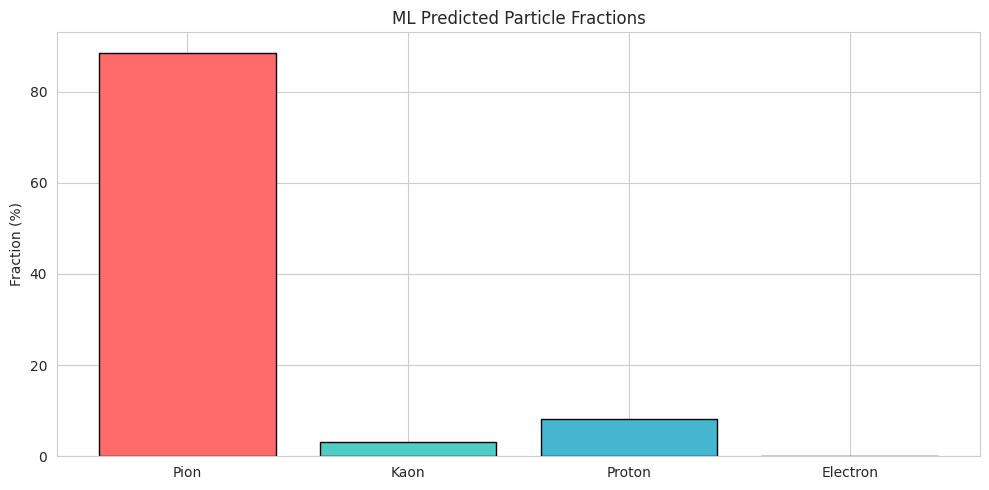

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
fractions = [(df_proc["ml_pred_class"] == i).mean() * 100 for i in range(4)]
ax.bar(PARTICLE_NAMES, fractions, color=COLORS, edgecolor="black")
ax.set_ylabel("Fraction (%)")
ax.set_title("ML Predicted Particle Fractions")
plt.tight_layout()
plt.savefig("plot_predicted_fractions.png", dpi=150, bbox_inches="tight")
plt.show()

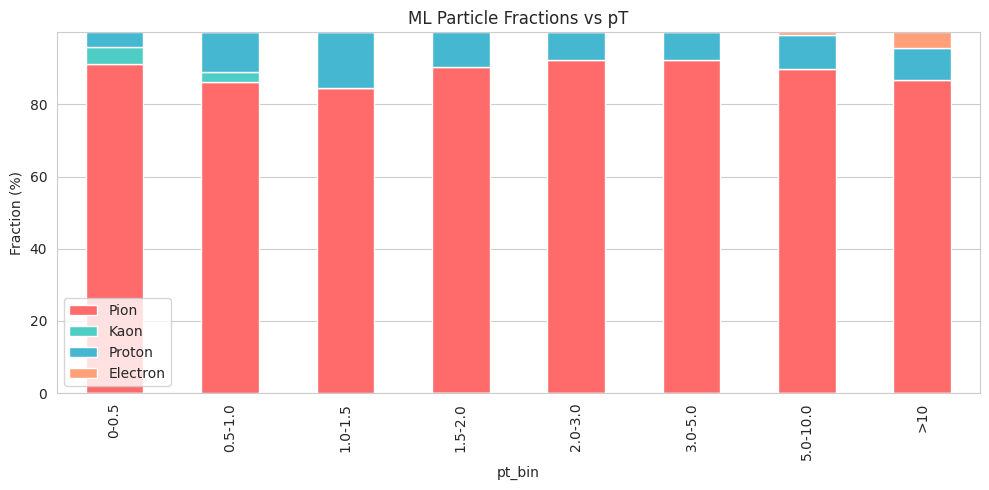

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
rows = []
for label in pt_labels:
    sub = df_proc[df_proc["pt_bin"] == label]
    if len(sub) == 0:
        continue
    rows.append({
        "pt_bin": label,
        "Pion": (sub["ml_pred_class"] == 0).mean() * 100,
        "Kaon": (sub["ml_pred_class"] == 1).mean() * 100,
        "Proton": (sub["ml_pred_class"] == 2).mean() * 100,
        "Electron": (sub["ml_pred_class"] == 3).mean() * 100,
    })

plot_frac = pd.DataFrame(rows)
plot_frac.set_index("pt_bin")[PARTICLE_NAMES].plot(kind="bar", stacked=True, ax=ax, color=COLORS)
ax.set_ylabel("Fraction (%)")
ax.set_title("ML Particle Fractions vs pT")
plt.tight_layout()
plt.savefig("plot_fractions_vs_pt.png", dpi=150, bbox_inches="tight")
plt.show()

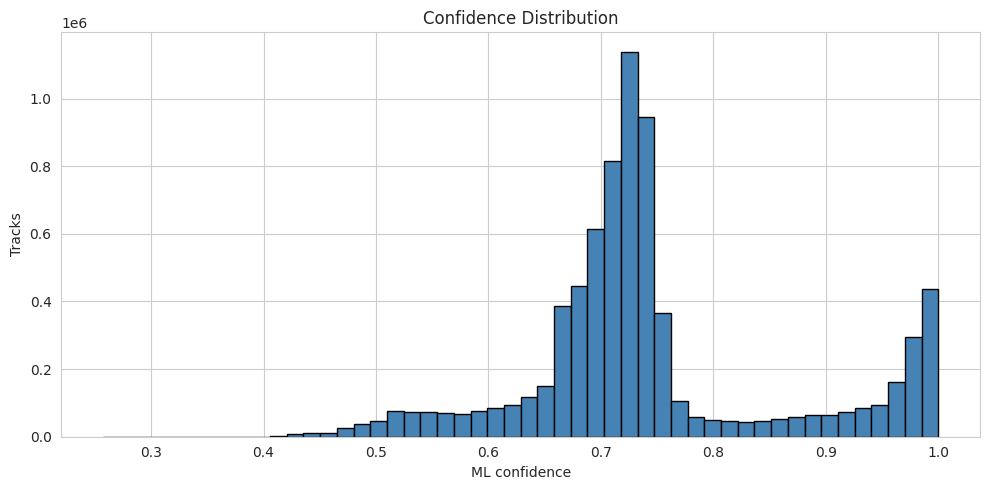

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_proc["ml_confidence"], bins=50, color="steelblue", edgecolor="black")
ax.set_xlabel("ML confidence")
ax.set_ylabel("Tracks")
ax.set_title("Confidence Distribution")
plt.tight_layout()
plt.savefig("plot_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()